In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv('/content/drive/MyDrive/data.csv',delimiter=';')
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=4424,n_classes=3,n_features=34,n_redundant=0,n_informative=34,random_state=42,n_clusters_per_class=1,flip_y=0.1)

In [5]:
X=pd.DataFrame(data=X)
y=pd.Series(data=y)
print(X.head())
print(y.head())

         0         1         2         3         4         5         6   \
0  0.105055  0.162385  1.869287  3.790286  0.891860 -4.220436  2.309536   
1 -4.213058 -1.357462  5.460102  3.241121  0.332932  4.070330 -3.204571   
2  3.144160 -1.183381  1.731005 -1.630701 -2.484022 -0.987886 -3.279077   
3 -2.807087 -2.024283  3.396589 -0.345353 -0.070444  0.464080 -2.874637   
4  0.396047 -1.648222  4.388881 -3.609490 -1.365633 -2.886085  6.454140   

         7         8         9   ...        24        25        26        27  \
0 -1.627833  2.919429 -1.408438  ... -5.725297 -1.291557 -0.550306  0.215059   
1 -0.594347  2.391984 -8.628409  ...  0.379959 -6.309818 -5.358263  4.099792   
2  1.753630  2.591382 -1.030013  ... -4.886887 -1.089283  1.214790  1.404187   
3 -6.814856 -1.937737  1.633297  ... -2.013770  3.241541  2.288069  2.072513   
4  0.552024 -0.453460  2.600327  ... -4.504642 -5.029232  2.404540  4.015235   

         28        29        30         31        32        33  
0 -

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)
print('No. of samples in train:',X_train.shape)

No. of samples in train: (3318, 34)


In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit(X_train)
X_train_std=sc.transform(X_train)
X_test_std=sc.transform(X_test)

Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
softmax_clf_std=LogisticRegression(multi_class='multinomial',solver='lbfgs')
softmax_clf_std.fit(X_train_std, y_train)

y_pred = softmax_clf_std.predict(X_test_std)
print(y_pred)
print(y_test)

[1 1 2 ... 2 2 2]
905     1
3410    1
4365    2
4114    0
3537    1
       ..
3804    0
391     1
1035    2
1188    2
3944    2
Length: 1106, dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification report for classifier LogisticRegression(multi_class='multinomial'):
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       372
           1       0.82      0.84      0.83       370
           2       0.79      0.78      0.79       364

    accuracy                           0.81      1106
   macro avg       0.81      0.81      0.81      1106
weighted avg       0.81      0.81      0.81      1106


Logistic Regression F1 Score (weighted average): 0.8137



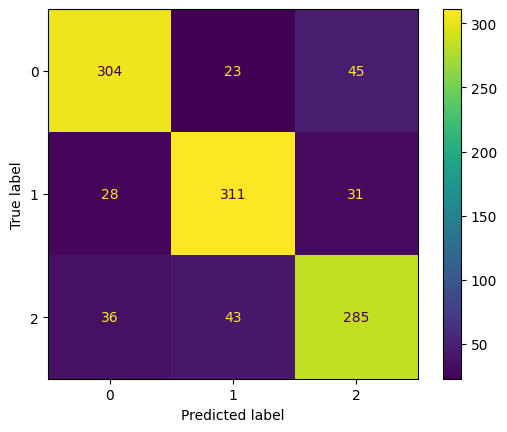

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics
print("Classification report for classifier %s:\n%s\n" % (softmax_clf_std,metrics.classification_report(y_test,y_pred)))

logreg_f1=metrics.f1_score(y_test, y_pred,average='weighted')
print(f'Logistic Regression F1 Score (weighted average): {logreg_f1:.4f}\n')

confMatrix = confusion_matrix(y_true=y_test,y_pred=y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confMatrix)
disp.plot()
plt.show()

SVM using RBF Kernel

In [10]:
from sklearn import datasets,svm,metrics
from sklearn.svm import SVC
RBF_Kernel_SVM=SVC(kernel='rbf',C=1,gamma=0.5,random_state=42)
RBF_Kernel_SVM.fit(X_train_std,y_train)
score_RBF_kernel=RBF_Kernel_SVM.score(X_test_std,y_test)
print(score_RBF_kernel)


0.337251356238698


In [11]:
RBF_Kernel_SVM=SVC(kernel='rbf',C=4,gamma=0.4,random_state=42)
RBF_Kernel_SVM.fit(X_train_std,y_train)
score_RBF_kernel=RBF_Kernel_SVM.score(X_test_std,y_test)
print(score_RBF_kernel)

y_pred = RBF_Kernel_SVM.predict(X_test_std)
print(y_pred[:10])

0.3987341772151899
[1 0 0 0 0 0 1 0 0 0]


In [12]:
from sklearn.metrics import f1_score
print('SVM_F1_Score: %.3f' % f1_score(y_true=y_test,y_pred=y_pred,average='weighted'))

SVM_F1_Score: 0.293


In [13]:
# Base Estimator
hpt_svm_clf=SVC(kernel='rbf')
hpt_svm_clf.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [14]:
hpt_param_grid=[{'C':[i for i in range(1,10)],'gamma': np.linspace(0.1,1,10)}]
hpt_param_grid

[{'C': [1, 2, 3, 4, 5, 6, 7, 8, 9],
  'gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}]

Hyperparameter Tuning Based on Grid Search

In [15]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=hpt_svm_clf,param_grid=hpt_param_grid,cv=5)
grid_search.fit(X_train_std,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                          'gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}])

In [16]:
best_svm_params=grid_search.best_params_
print("Best parameters found:",best_svm_params)

best_svm_score=grid_search.best_score_
print('Best SVM Score:',best_svm_score)

best_svm_clf=grid_search.best_estimator_
print(best_svm_clf)

Best parameters found: {'C': 1, 'gamma': np.float64(0.1)}
Best SVM Score: 0.9165194715513639
SVC(C=1, gamma=np.float64(0.1))


In [17]:
best_svm_clf_rbf=SVC(kernel='rbf',C=1,gamma=0.1,random_state=42)
best_svm_clf_rbf.fit(X_train_std,y_train)
best_svm_predicted=(best_svm_clf_rbf.predict(X_test_std))

from sklearn.metrics import f1_score
Best_svm_F1_Score = f1_score(y_true = y_test, y_pred = best_svm_predicted, average = 'weighted')
print('Best_SVM_F1_Score: %.3f' % f1_score(y_true = y_test, y_pred = best_svm_predicted, average = 'weighted'))

Best_SVM_F1_Score: 0.924


In [18]:
data_columns=data.columns[2:36]
print(data_columns)
print(data_columns.shape)

Index(['Application order', 'Course', 'Daytime/evening attendance\t',
       'Previous qualification', 'Previous qualification (grade)',
       'Nacionality', 'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd s

Decision Tree

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dtree_clf=DecisionTreeClassifier(random_state=42)
dtree_clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [20]:
hpt_param_grid=[{'max_depth':[i for i in range(1,10)],'max_features':[i for i in range(1,36)]}]
grid_search=GridSearchCV(estimator=dtree_clf,param_grid=hpt_param_grid,cv=5)
grid_search.fit(X_train_std,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid=[{'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                          'max_features': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                           12, 13, 14, 15, 16, 17, 18, 19, 20,
                                           21, 22, 23, 24, 25, 26, 27, 28, 29,
                                           30, ...]}])

In [21]:
best_dtree_params=grid_search.best_params_
print("Best parameters found for Decision Tree:",best_dtree_params)

best_dtree_score=grid_search.best_score_
print('Best Decision Tree Score:',best_dtree_score)

best_dtree_clf=grid_search.best_estimator_
print(best_dtree_clf)

Best parameters found for Decision Tree: {'max_depth': 9, 'max_features': 15}
Best Decision Tree Score: 0.6561240436860565
DecisionTreeClassifier(max_depth=9, max_features=15, random_state=42)


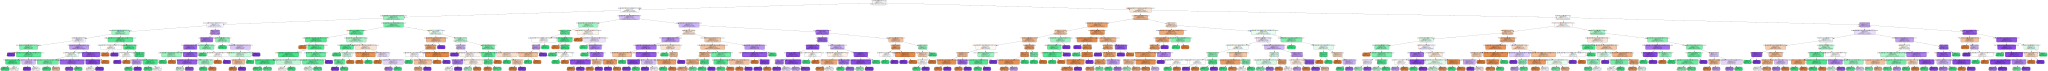

In [22]:
from sklearn.tree import export_graphviz
export_graphviz(best_dtree_clf, out_file="best_data.dot",feature_names=data_columns,rounded=True,filled=True)

from graphviz import Source
Source.from_file("best_data.dot")

In [23]:
best_dtree_clf_predicted=best_dtree_clf.predict(X_test_std)
from sklearn.metrics import f1_score
best_dtree_F1_score = f1_score(y_true=y_test,y_pred=best_dtree_clf_predicted,average='weighted')
print('Best_DecisionTree_F1_score: %.3f' % f1_score(y_true=y_test,y_pred=best_dtree_clf_predicted,average='weighted'))

Best_DecisionTree_F1_score: 0.674


Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
randf_clf=RandomForestClassifier(random_state = 42)
randf_clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [25]:
hpt_param_grid=[{'max_features':[i for i in range(1,10)],'max_leaf_nodes':[i for i in range(2,10)]}]
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=randf_clf,param_grid=hpt_param_grid,cv=5)
grid_search.fit(X_train_std,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid=[{'max_features': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                          'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9]}])

In [26]:
best_randf_params=grid_search.best_params_
print("Best parameters found for Random Forest:",best_randf_params)\

best_randf_score=grid_search.best_score_
print('Best Random Forest Score:',best_randf_score)

best_randf_clf = grid_search.best_estimator_
print(best_randf_clf)

Best parameters found for Random Forest: {'max_features': 4, 'max_leaf_nodes': 9}
Best Random Forest Score: 0.7748732486507114
RandomForestClassifier(max_features=4, max_leaf_nodes=9, random_state=42)


In [27]:
best_randf_clf_predicted=best_randf_clf.predict(X_test_std)
from sklearn.metrics import f1_score
best_randf_F1_score=f1_score(y_true=y_test,y_pred=best_randf_clf_predicted,average='weighted')
print('Best_Random_Forest_F1_Score: %.3f' % f1_score(y_true=y_test,y_pred=best_randf_clf_predicted,average='weighted'))

Best_Random_Forest_F1_Score: 0.777


AdaBoost

In [28]:
from sklearn.ensemble import AdaBoostClassifier
ada_boost_clf=AdaBoostClassifier(DecisionTreeClassifier(random_state=42))
ada_boost_clf.get_params()

{'algorithm': 'deprecated',
 'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'gini',
 'estimator__max_depth': None,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 42,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(random_state=42),
 'learning_rate': 1.0,
 'n_estimators': 50,
 'random_state': None}

In [29]:
hpt_param_grid=[{'n_estimators': [100, 150, 200, 250, 300],'learning_rate': [0.1, 1.0, 0.1]}]
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=ada_boost_clf,param_grid=hpt_param_grid,cv=5)
grid_search.fit(X_train_std,y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42)),
             param_grid=[{'learning_rate': [0.1, 1.0, 0.1],
                          'n_estimators': [100, 150, 200, 250, 300]}])

In [30]:
best_ada_boost_params=grid_search.best_params_
print("Best parameters found for AdaBoost:", best_ada_boost_params)

best_ada_boost_score=grid_search.best_score_
print('Best AdaBoost Score:',best_ada_boost_score)

best_ada_boost_clf=grid_search.best_estimator_
print(best_ada_boost_clf)

Best parameters found for AdaBoost: {'learning_rate': 0.1, 'n_estimators': 250}
Best AdaBoost Score: 0.6314052590452307
AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                   learning_rate=0.1, n_estimators=250)


In [31]:
best_ada_boost_clf_predicted=best_ada_boost_clf.predict(X_test_std)
from sklearn.metrics import f1_score
best_ada_boost_F1_score=f1_score(y_true=y_test,y_pred=best_ada_boost_clf_predicted,average='weighted')
print('Best_AdaBoost_F1_Score: %.3f' % f1_score(y_true=y_test,y_pred=best_ada_boost_clf_predicted,average='weighted'))

Best_AdaBoost_F1_Score: 0.650


Gradient Boost

In [32]:
from sklearn.ensemble import GradientBoostingClassifier
grad_boost_clf=GradientBoostingClassifier(random_state=42)
grad_boost_clf.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [33]:
hpt_param_grid=[{'n_estimators': [100, 150, 200, 250, 300]}]
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=grad_boost_clf,param_grid=hpt_param_grid,cv=5)
grid_search.fit(X_train_std,y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             param_grid=[{'n_estimators': [100, 150, 200, 250, 300]}])

In [34]:
best_grad_boost_params=grid_search.best_params_
print("Best parameters found for Gradient Boosting:",best_grad_boost_params)

best_grad_boost_score=grid_search.best_score_
print('Best Gradient Boosting Score:',best_grad_boost_score)

best_grad_boost_clf=grid_search.best_estimator_
print(best_grad_boost_clf)

Best parameters found for Gradient Boosting: {'n_estimators': 300}
Best Gradient Boosting Score: 0.8532260262770539
GradientBoostingClassifier(n_estimators=300, random_state=42)


In [35]:
best_grad_boost_clf_predicted=best_grad_boost_clf.predict(X_test_std)
from sklearn.metrics import f1_score
best_grad_boost_F1_score=f1_score(y_true=y_test,y_pred=best_grad_boost_clf_predicted,average='weighted')
print('Best_Gradient_Boosting_F1_score: %.3f' % f1_score(y_true=y_test,y_pred=best_grad_boost_clf_predicted,average='weighted'))

Best_Gradient_Boosting_F1_score: 0.865


In [36]:
import plotly.graph_objects as gr
import pandas as pd

data={"Model": ['Kernal(RBF)SVM_Std','Desicion_Trees','Random_Forest','Ada_Boost','Gradient_Boost'],
        "F1_scores_before_Tuning": [0.73, 0.68, 0.75, 0.68, 0.75],
        "F1_scores_after_Tuning": [round(Best_svm_F1_Score,3),round(best_dtree_F1_score,3),round(best_randf_F1_score,3),round(best_ada_boost_F1_score,3),round(best_grad_boost_F1_score,3)]}

df=pd.DataFrame(data)

fig=gr.Figure(data=[gr.Table(header=dict(values=list(df.columns),align='center'),cells=dict(values=[df.Model, df.F1_scores_before_Tuning, df.F1_scores_after_Tuning], align='center'))])
fig.show()

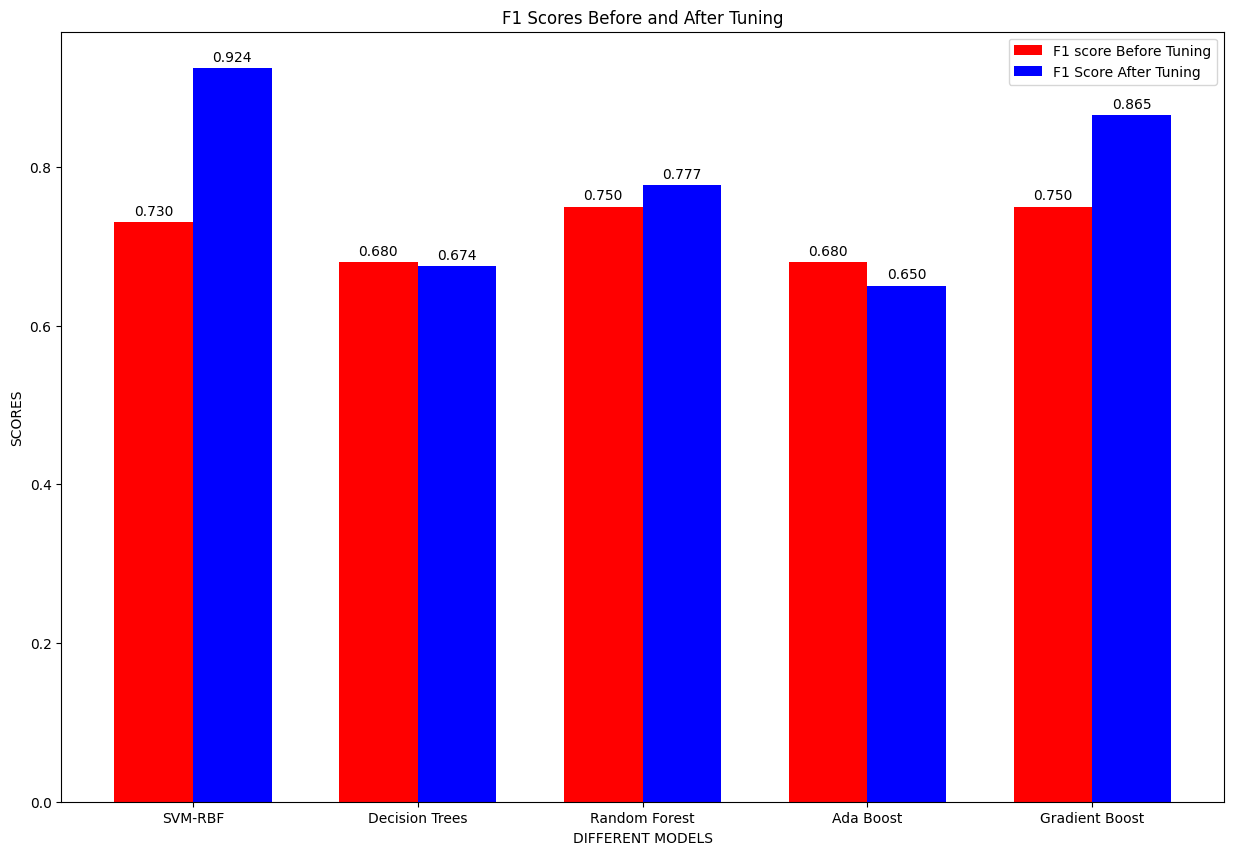

In [37]:
import matplotlib.pyplot as plt
import numpy as np

models=['SVM-RBF','Decision Trees','Random Forest','Ada Boost','Gradient Boost']
scores_before=[0.73, 0.68, 0.75, 0.68, 0.75]
scores_after=[Best_svm_F1_Score,best_dtree_F1_score,best_randf_F1_score,best_ada_boost_F1_score,best_grad_boost_F1_score]

x=np.arange(len(models))
width=0.35

fig,ax=plt.subplots(figsize=(15,10))
rects1=ax.bar(x - width/2,scores_before,width,label='F1 score Before Tuning',color= 'Red')
rects2=ax.bar(x + width/2,scores_after,width,label='F1 Score After Tuning',color= 'Blue')

ax.set_ylabel('SCORES')
ax.set_title('F1 Scores Before and After Tuning')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_xlabel('DIFFERENT MODELS')
ax.legend()

for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',xy=(rect.get_x()+rect.get_width()/2, height),xytext=(0,3),textcoords="offset points",ha='center',va='bottom')

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',xy=(rect.get_x()+rect.get_width()/2, height),xytext=(0,3),textcoords="offset points",ha='center',va='bottom')


plt.show()

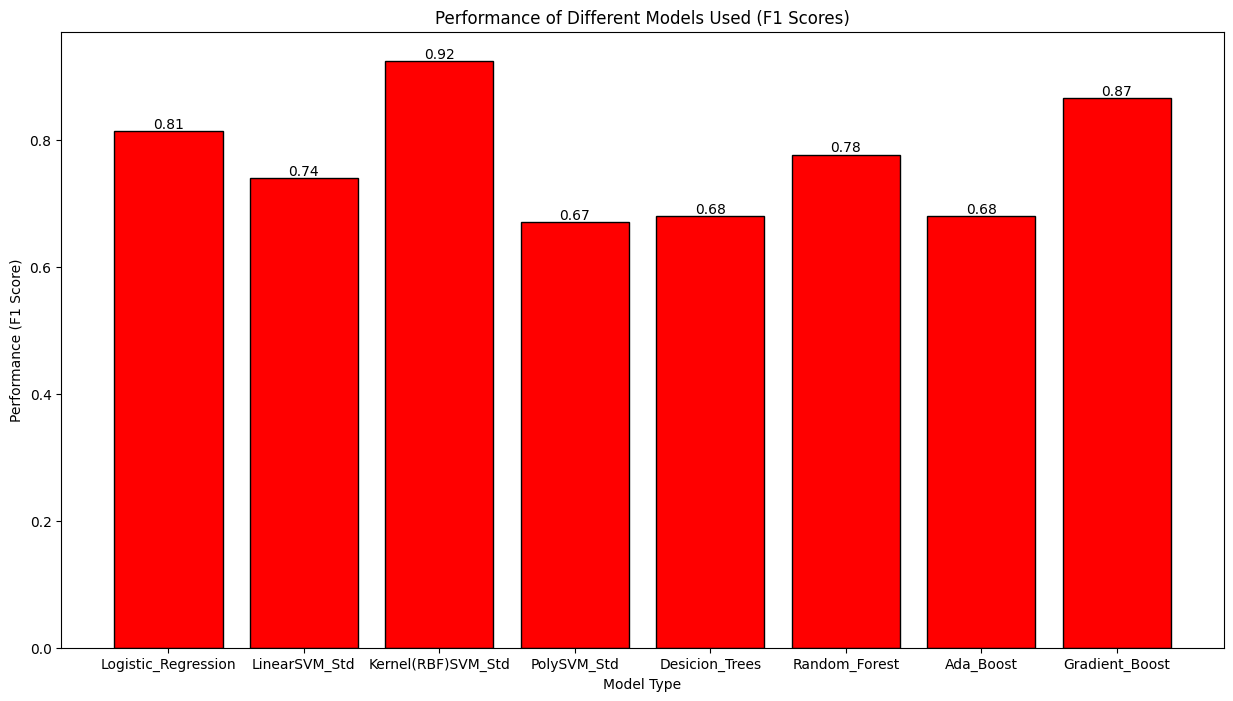

In [39]:
x_axis=["Logistic_Regression","LinearSVM_Std","Kernel(RBF)SVM_Std","PolySVM_Std","Desicion_Trees","Random_Forest","Ada_Boost","Gradient_Boost"]
y_axis=[logreg_f1,0.74,Best_svm_F1_Score,0.67,0.68,best_randf_F1_score,0.68,best_grad_boost_F1_score]

plt.figure(figsize=(15, 8))
bars=plt.bar(x_axis,y_axis, color='red',edgecolor = "black")

i = 0
while i <= 7:
  for bar in bars:
    plt.text(i,y_axis[i],round(y_axis[i],2),horizontalalignment='center',verticalalignment='bottom')
    i=i+1

plt.plot()
plt.ylabel("Performance (F1 Score)")
plt.xlabel("Model Type")
plt.title("Performance of Different Models Used (F1 Scores)")
plt.show()